In [1]:
import tensorflow as tf
import numpy as np
from sklearn.tree import DecisionTreeClassifier
import matplotlib.pyplot as plt

In [2]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

In [3]:
x_train=x_train/255.0
x_test=x_test/255.0

In [26]:
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
inputs = Input(shape=(28, 28, 1))
x = Conv2D(16, 3, activation='relu', padding='same')(inputs)
x = MaxPooling2D()(x)
x = Conv2D(32, 3, activation='relu', padding='same')(x)
x = MaxPooling2D()(x)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
logits = Dense(10)(x)  # raw output, no softmax

model = Model(inputs=inputs, outputs=logits)
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True))
model.fit(x_train, y_train, epochs=3, batch_size=64)

Epoch 1/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 19ms/step - loss: 0.4156
Epoch 2/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 21s 20ms/step - loss: 0.0564
Epoch 3/3
938/938 ━━━━━━━━━━━━━━━━━━━━ 20s 20ms/step - loss: 0.0399


In [27]:
logit_model = Model(inputs=model.input, outputs=model.output)
X_train = logit_model.predict(x_train)
X_test = logit_model.predict(x_test)

1875/1875 ━━━━━━━━━━━━━━━━━━━━ 16s 8ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


Surrogate accuracy: 60.82%


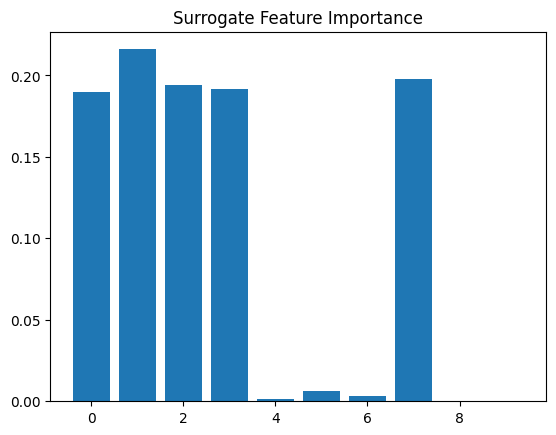

In [28]:
from sklearn.tree import plot_tree
dt = DecisionTreeClassifier(max_depth=5)
dt.fit(X_train, y_train)
print(f"Surrogate accuracy: {dt.score(X_test, y_test)*100:.2f}%")

# Feature importance
plt.bar(range(10), dt.feature_importances_)
plt.title("Surrogate Feature Importance")
plt.show()

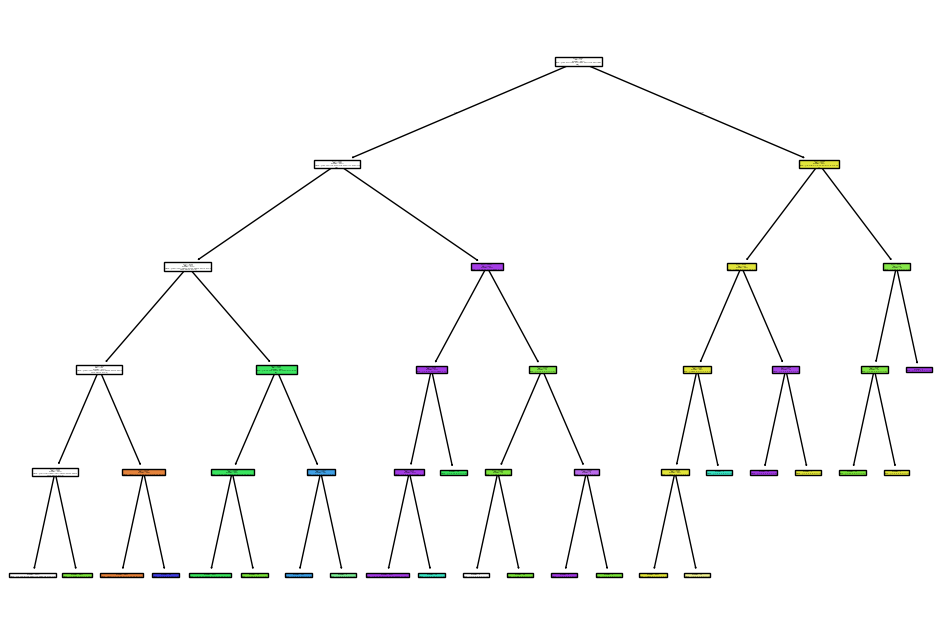

In [32]:
plt.figure(figsize=(12,8))
plot_tree(dt, filled=True)
plt.show()